# nb13 — Joint RNA, ATAC and protein integration

Fit a **new three-modality MultiVI model** across CITE (RNA+protein) and Multiome
(RNA+ATAC), connected by common RNA. Previous totalVI/MultiVI latent axes are not
merged. Cells remain distinct, including repeated barcodes across captures.

This pilot reuses raw counts from nb11 and nb12 model_input.h5ad files. RNA features
are the **intersection of their selected HVG panels**, not the complete shared RNA
universe. Peaks and proteins remain frozen to nb12/nb11 respectively. The input audit
reports the actual intersection size; feature restrictions limit interpretation.

TRAIN once in a fresh GPU runtime and folder. Return with LOAD (default). Use
EVALUATE to rebuild analysis from saved weights without retraining. Copy this
notebook and src/joint_integration.py into the existing Drive project; the existing
src helper files remain dependencies. nb01–12 stay unchanged.

In [1]:
from pathlib import Path
import sys,json,subprocess
MODE='TRAIN'  # TRAIN for first run; EVALUATE only to rebuild saved analysis
assert MODE in {'LOAD','TRAIN','EVALUATE'}
try:
    from google.colab import drive
    IN_COLAB=True
except ImportError:
    IN_COLAB=False
if IN_COLAB:
    drive.mount('/content/drive')
    BASE=Path('/content/drive/MyDrive/multiomics-relationship-modeling')
else:
    BASE=Path.cwd().resolve()
    if not (BASE/'src').is_dir():BASE=BASE.parent
if MODE!='LOAD':
    subprocess.check_call([sys.executable,'-m','pip','install','-q',
        'scvi-tools==1.4.3','scanpy>=1.11,<1.12','anndata>=0.11,<0.13'])
sys.path.insert(0,str(BASE))
import pandas as pd
from IPython.display import display,Image
CITE_RUN=BASE/'results/totalvi/nb11_run01'
MULTIOME_RUN=BASE/'results/multivi/nb12_run01'
OUTPUT=BASE/'results/joint_integration/nb13_run01'
SEED=42
TRAINING=dict(max_epochs=300,min_epochs=100,warmup_epochs=50,patience=30,
              accelerator='auto',batch_size=128,n_latent=30)
print('Mode:',MODE,'Output:',OUTPUT)

Mounted at /content/drive
Mode: TRAIN Output: /content/drive/MyDrive/multiomics-relationship-modeling/results/joint_integration/nb13_run01


## Input and missing-modality contract
Each upstream folder must contain model_input.h5ad, manifest.json and status.json.
The cohort fingerprints must agree. Source input hashes, ordered feature names,
cell IDs and counts are recorded. Raw RNA/protein/peak counts are checked.
Cells with zero selected RNA or zero measured modality counts are excluded and audited.

CITE ATAC rows and Multiome protein rows contain **storage placeholders**. Explicit
observed-modality flags are saved; MultiVI 1.4.3 detects whole missing modalities
from zero row totals and masks their likelihood contributions. Individual zeros
within measured modalities remain observations. We test this behavior in synthetic
mixed-capture minibatches; no absent modality is presented as a measured zero.

Assay is the batch variable, with adversarial mixing enabled. Donor/site and cell-type
labels are not nuisance covariates or training supervision. The default modality
alignment penalty remains active. RNA likelihood NB, hidden width 128, latent size 30.
Train on raw counts with 50-epoch KL warm-up, 100–300 epochs, and validation ELBO
patience 30 after warm-up. Final weights are saved. This correction choice can remove
real capture-associated biology, so evaluate preservation as well as mixing.

No missing-modality predictions are exported in this first notebook. A shared
embedding does not validate protein–ATAC relationships or provide paired cells.

[MultiVI three-modality API](https://docs.scvi-tools.org/en/stable/api/reference/scvi.model.MULTIVI.html)

In [2]:
if MODE=='TRAIN':
    from src.joint_integration import run_joint
    run_joint(CITE_RUN,MULTIOME_RUN,OUTPUT,seed=SEED,**TRAINING)
elif MODE=='EVALUATE':
    from src.joint_integration import evaluate_saved
    evaluate_saved(OUTPUT,seed=SEED)
else:
    print('Training skipped; loading saved results below.')

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


INFO     Found batches with missing protein expression                                                             


/usr/local/lib/python3.13/dist-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=1, join_common=join_common)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: You are 

Training:   0%|          | 0/300 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 30 records. Best score: 3033.117. Signaling Trainer to stop.


In [3]:
files=['metric_comparison.csv','celltype_alignment.csv','donor_celltype_alignment.csv','depth_associations.csv']
missing=[n for n in files if not (OUTPUT/n).exists()]
if missing:
    raise FileNotFoundError(f'Missing {missing}. First run: TRAIN. If weights and model_input.h5ad '
                            'already exist here, choose EVALUATE rather than retraining.')
comparison,types,donors,depths=[pd.read_csv(OUTPUT/n) for n in files]
for name in ['status.json','input_audit.json','training_summary.json','evaluation_status.json']:
    if (OUTPUT/name).exists():
        print(name);display(json.loads((OUTPUT/name).read_text()))

status.json


{'state': 'complete', 'biological_review': 'required'}

input_audit.json


{'n_cells': 141039,
 'n_shared_genes': 994,
 'n_peaks': 20000,
 'n_proteins': 134,
 'excluded_zero_observed_cells': 0,
 'feature_scope': 'Intersection of nb11/nb12 RNA HVGs; frozen nb12 peaks and nb11 proteins. Not all shared RNA genes.',
 'missingness': 'CITE ATAC and Multiome protein rows are storage placeholders masked by MultiVI; never measured zeros.',
 'source_model_input_sha256': {'cite': '25e2d551c1cd6cfd89a63bfd1776357c11b8be7572315fe3881c0a2a0b3be7e7',
  'multiome': 'c96066b4d14e084ebdec4220804142c40ee0b89aa369b2ac7c3e3a11db1d8f19'}}

training_summary.json


{'epochs_completed': 170,
 'best_validation_epoch': 139,
 'final_validation_elbo': 3034.95751953125,
 'final_kl_weight': 1.0,
 'reached_epoch_limit': False,
 'warmup_epochs': 50,
 'note': 'Final weights, not restored best checkpoint. Review curves and biology.'}

evaluation_status.json


{'state': 'complete',
 'n_evaluation_cells': 19670,
 'outputs_sha256': {'cell_audit.csv': '221a7d4066aa104f347c8deaa19a2b600fc4462567966a80881e536eceae08cf',
  'cohort_counts.csv': '8c916ae7b41248c33ebf3960a51069a25f2120e71b37041778744cef12f47d27',
  'shared_genes.csv': '148860bb5a76f04cade618031521e186c00664f61b9d6ae8846b143ab0f1ffbc',
  'training_kl_weight.csv': '3a93e0d4126f343bfc25e416dc12c537ce9b680842d344bec273274321deed7f',
  'training_validation_loss.csv': '746c860fb49baba2cf14eae0d0490a9d47371e5bc52b6c86d1faead74385cb6d',
  'training_elbo_validation.csv': '1cfa53cb04be4283a1dd1f6886164a87cae96bb49524192958d607426304e762',
  'training_reconstruction_loss_validation.csv': 'cb094777827ef594b7eb5f4ab9e91e4db521e5c6e1d2284e92aa2cda5f2d41b9',
  'training_kl_local_validation.csv': 'e266a7a9fba05840ae4e3bb5d131b0a3668549941427e2542d4bd2a0fe4fe4d4',
  'training_kl_global_validation.csv': '107e8a421a911f5f9580025b4d8f6381d7833dd4b54023164cc8e91e6e4ca5f8',
  'training_train_loss.csv': '0

## Does a common space preserve cell identity?
Compare the joint model with RNA PCA on the exact same shared RNA panel and fixed
assay/donor-quota sample (up to 20,000 resolved cells). RNA PCA is a baseline, not a
matched-complexity ablation: changes cannot be uniquely attributed to ATAC/protein.
Silhouette uses at most 3,000 cells. Unresolved labels train but do not evaluate.

Within-type and donor/type mixing use equal assay query weights and normalize
by random-mixing expectation. Require 50 evaluation cells per assay, retain
insufficient groups. Exploratory labels: supported when mixing ratio >=0.8 and
scaled centroid distance <=0.5; concern when ratio <0.5 or distance >1; otherwise
partial. These labels are diagnostics, not an automatic go/no-go rule.

Inspect cell-type purity and silhouette loss, minority populations, donor/site
structure and depth associations **within each assay**, excluding unmeasured-depth
placeholders. RNA-profile correlations use normalized observed RNA and cannot
improve because of embedding integration. No cell-level inferential p-values.

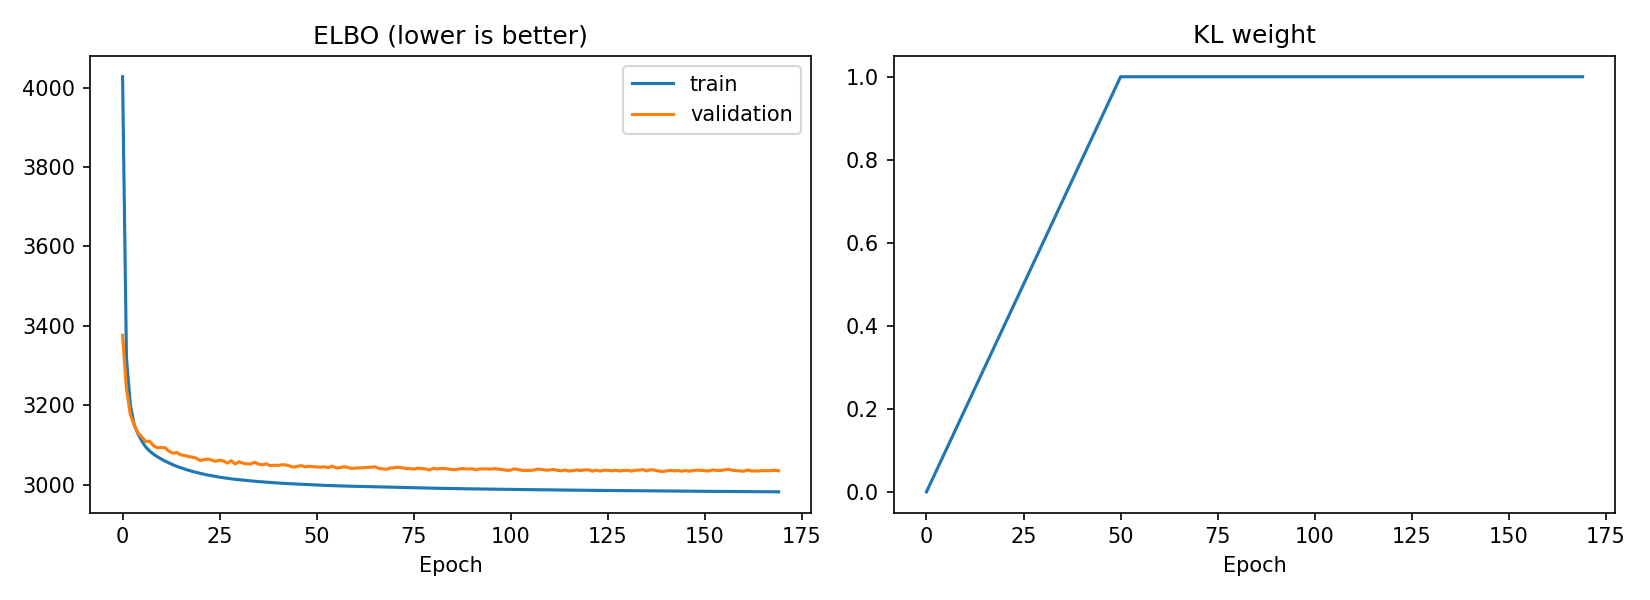

,metric,rna_pca,joint,change
0,cell_type_purity,0.873667,0.906426,0.032759
1,cell_type_entropy,0.085480,0.060782,-0.024698
2,cell_type_knn_label_agreement,0.922928,0.939197,0.016268
3,cell_type_silhouette,0.093353,0.180655,0.087302
4,assay_purity,0.981374,0.880273,-0.101102
5,assay_entropy,0.048229,0.316473,0.268244
6,assay_knn_label_agreement,0.988155,0.939451,-0.048704
7,assay_silhouette,0.106533,0.012804,-0.093729
8,donor_purity,0.463637,0.591359,0.127722
9,donor_entropy,0.548204,0.393823,-0.154382


,cell_type_harmonized,n_CITE,n_Multiome,sufficient_cells,cross_assay_fraction,expected_cross_fraction,mixing_ratio,centroid_distance,scaled_centroid_distance,alignment_status,space
0,B cells,940,1043,True,0.009773,0.500252,0.019537,17.207375,1.382703,concern,rna_pca
1,CD4 T cells,1504,1635,True,0.018633,0.500159,0.037255,15.452095,1.368322,concern,rna_pca
2,CD8 T cells,1434,1836,True,0.022721,0.500153,0.045428,13.811708,1.100332,concern,rna_pca
3,CD14 monocytes,2347,1878,True,0.000985,0.500118,0.001970,18.538836,1.770450,concern,rna_pca
4,CD16 monocytes,307,275,True,0.029076,0.500861,0.058051,15.245815,1.479774,concern,rna_pca
5,Erythroid populations,1215,1213,True,0.035090,0.500206,0.070151,15.843658,1.423689,concern,rna_pca
6,G/M progenitors,210,161,True,0.013433,0.501351,0.026794,18.573469,1.456711,concern,rna_pca
7,HSC,197,136,True,0.018175,0.501506,0.036240,18.172825,1.579924,concern,rna_pca
8,ILC,25,122,False,NaN,NaN,NaN,NaN,NaN,insufficient cells,rna_pca
9,Lymphoid progenitors,185,189,True,0.026152,0.501340,0.052164,16.209713,1.175772,concern,rna_pca


,DonorID,cell_type_harmonized,n_CITE,n_Multiome,sufficient_cells,cross_assay_fraction,expected_cross_fraction,mixing_ratio,centroid_distance,scaled_centroid_distance,alignment_status,rna_profile_pearson,full_n_CITE,full_n_Multiome,space
0,10886,B cells,111,45,False,NaN,NaN,NaN,NaN,NaN,insufficient cells,0.822099,446,288,rna_pca
1,10886,CD4 T cells,355,390,True,0.025081,0.500672,0.050094,13.505636,1.228181,concern,0.814003,1367,1998,rna_pca
2,10886,CD8 T cells,131,281,True,0.040506,0.501217,0.080814,10.720998,0.964267,concern,0.881589,554,1632,rna_pca
3,10886,CD14 monocytes,189,113,True,0.019519,0.501661,0.038909,15.397330,1.458993,concern,0.829707,726,704,rna_pca
4,10886,CD16 monocytes,39,40,False,NaN,NaN,NaN,NaN,NaN,insufficient cells,0.896227,142,179,rna_pca
5,10886,Erythroid populations,102,39,False,NaN,NaN,NaN,NaN,NaN,insufficient cells,0.825695,402,235,rna_pca
6,10886,G/M progenitors,26,7,False,NaN,NaN,NaN,NaN,NaN,insufficient cells,NaN,86,27,rna_pca
7,10886,HSC,16,10,False,NaN,NaN,NaN,NaN,NaN,insufficient cells,NaN,72,33,rna_pca
8,10886,ILC,18,75,False,NaN,NaN,NaN,NaN,NaN,insufficient cells,0.879381,86,367,rna_pca
9,10886,Lymphoid progenitors,7,12,False,NaN,NaN,NaN,NaN,NaN,insufficient cells,NaN,27,28,rna_pca


,space,assay,depth,max_absolute_spearman
0,rna_pca,CITE,shared_rna_counts,0.362147
1,rna_pca,CITE,protein_counts,0.346575
2,rna_pca,Multiome,shared_rna_counts,0.671057
3,rna_pca,Multiome,atac_counts,0.211075
4,joint,CITE,shared_rna_counts,0.615878
5,joint,CITE,protein_counts,0.955949
6,joint,Multiome,shared_rna_counts,0.420327
7,joint,Multiome,atac_counts,0.325383


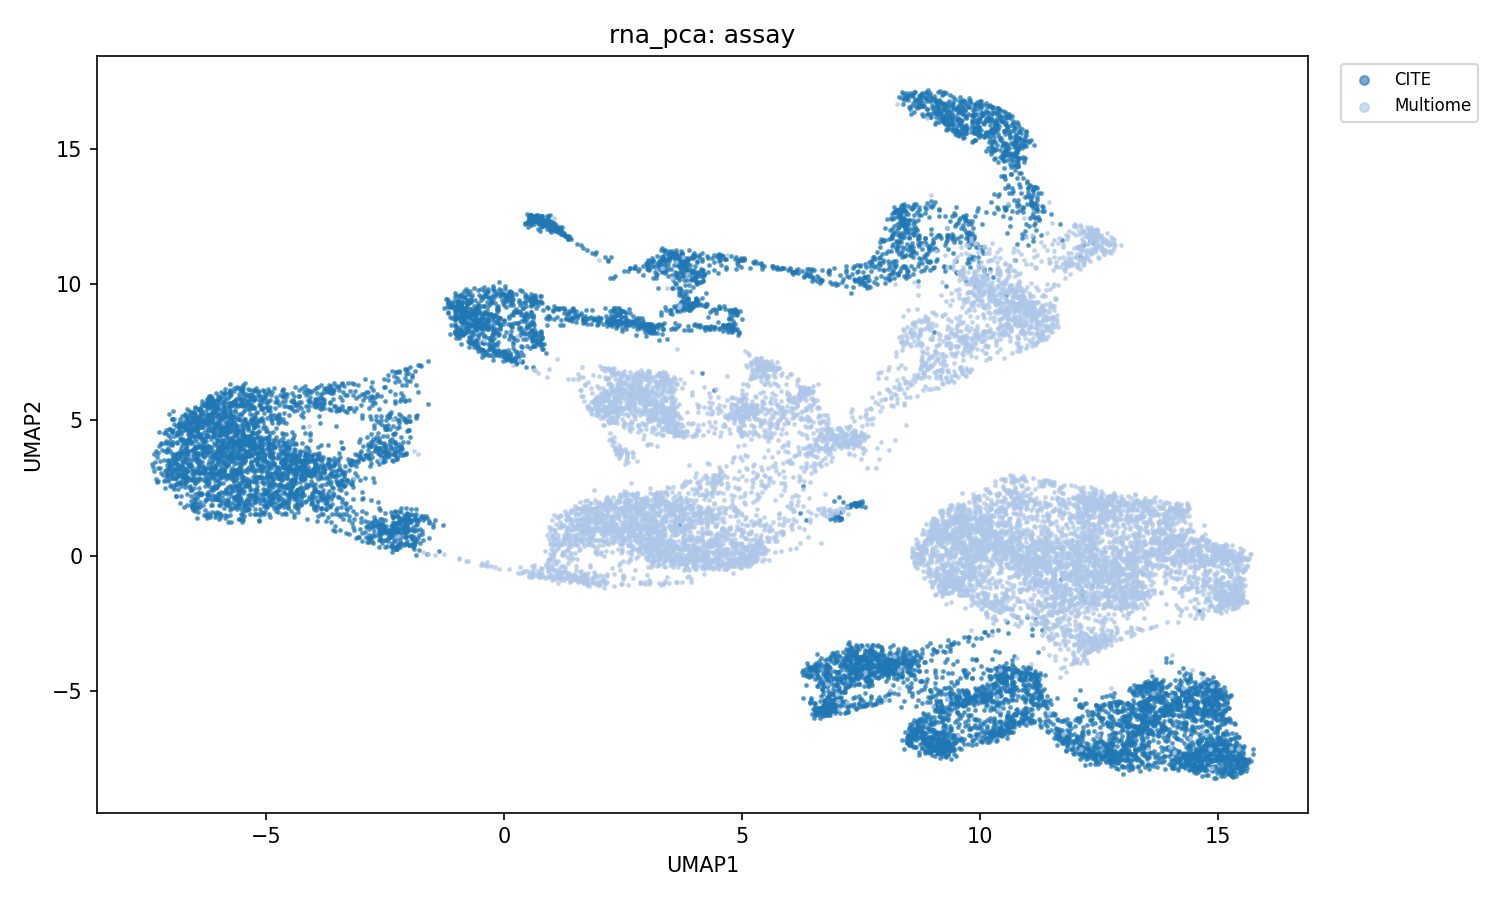

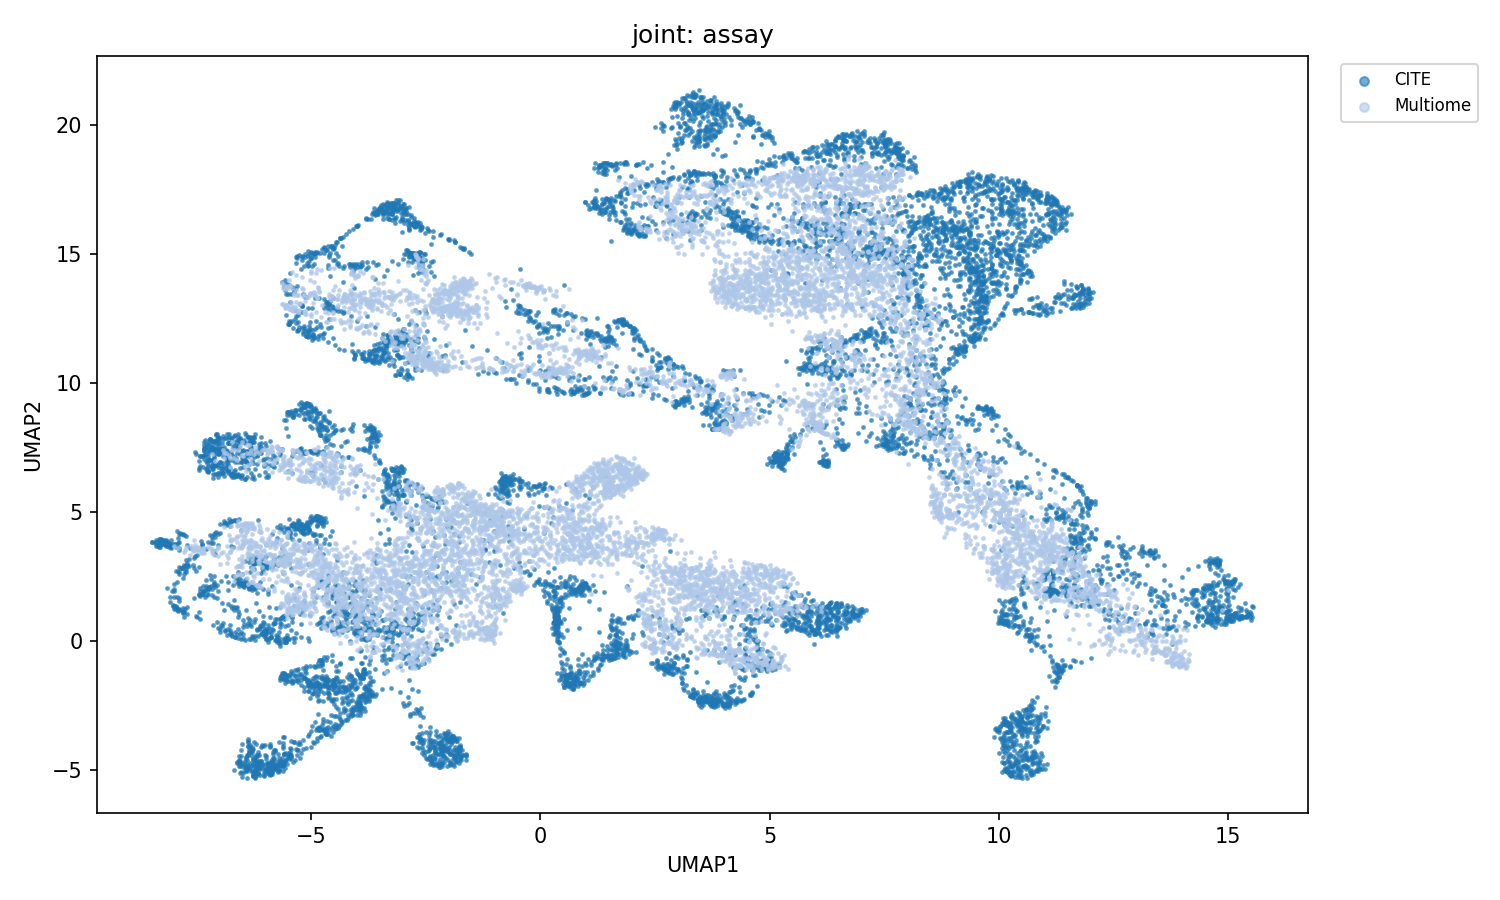

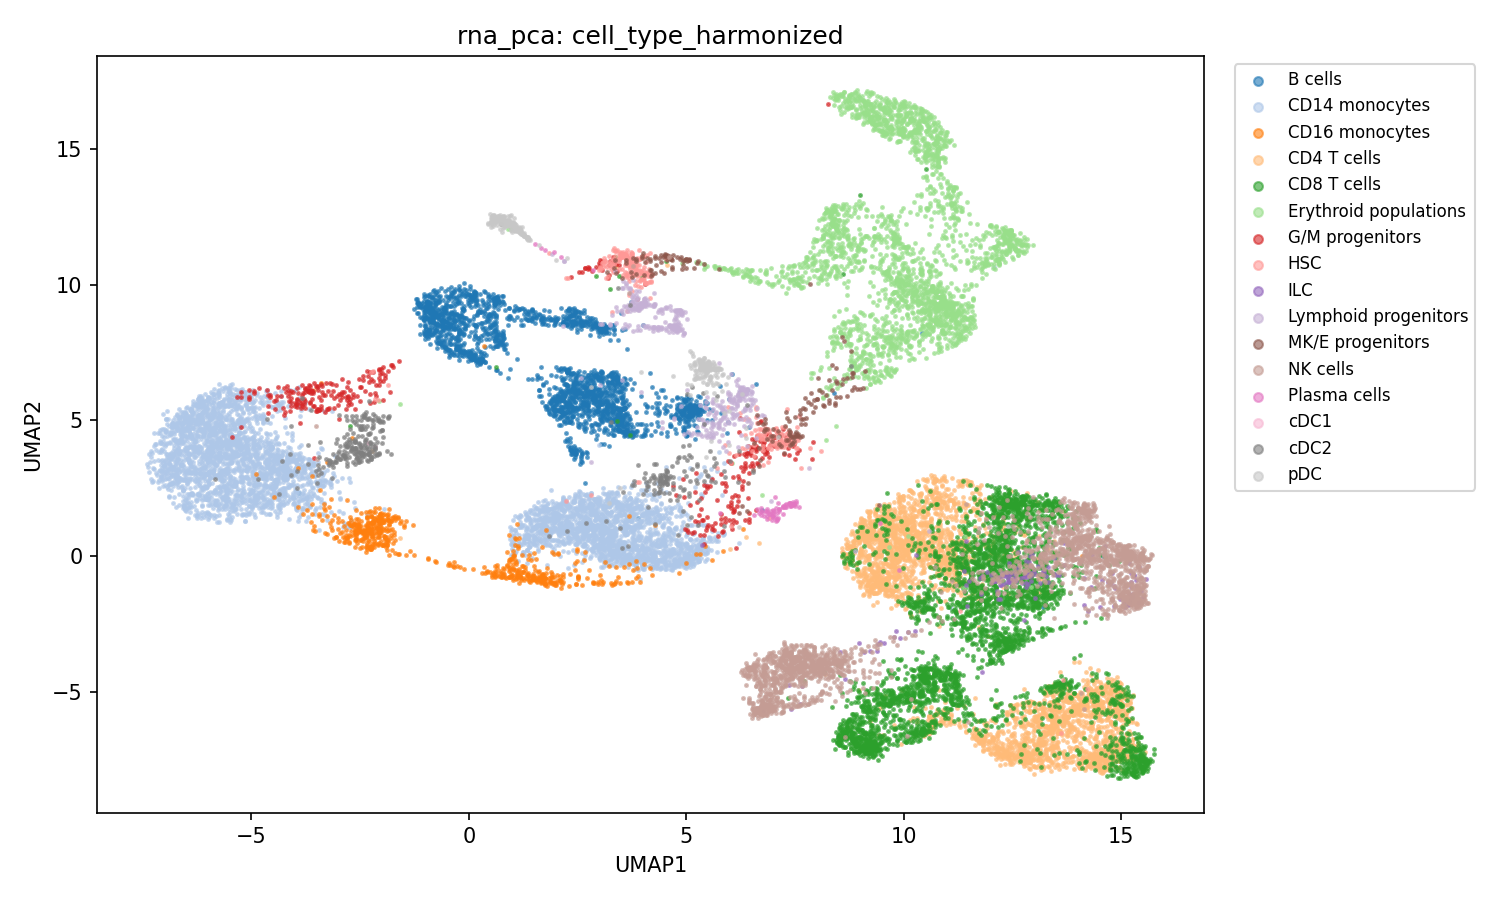

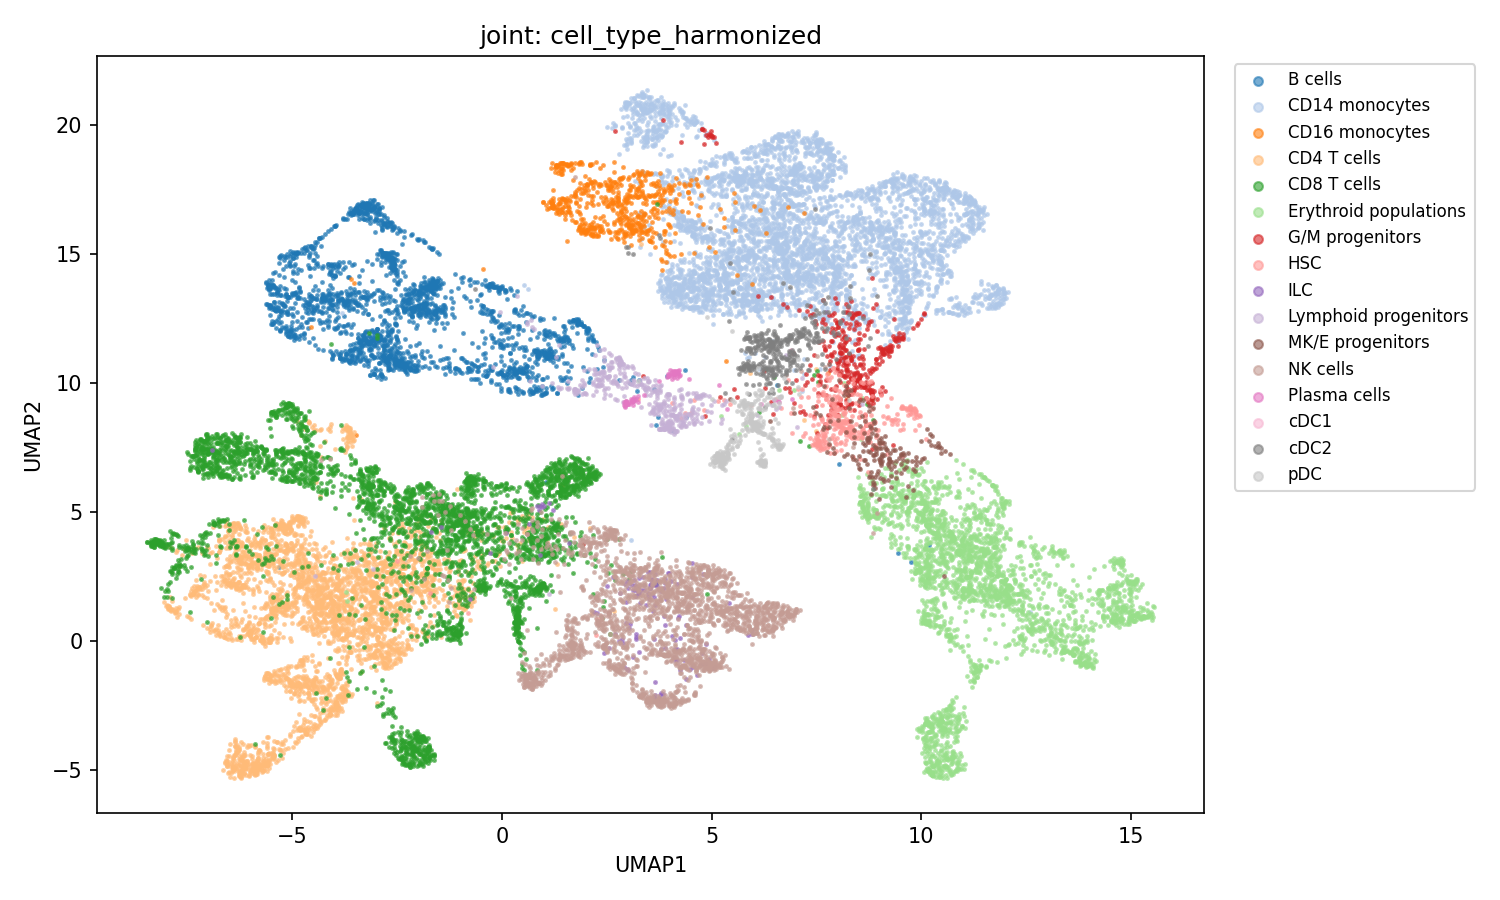

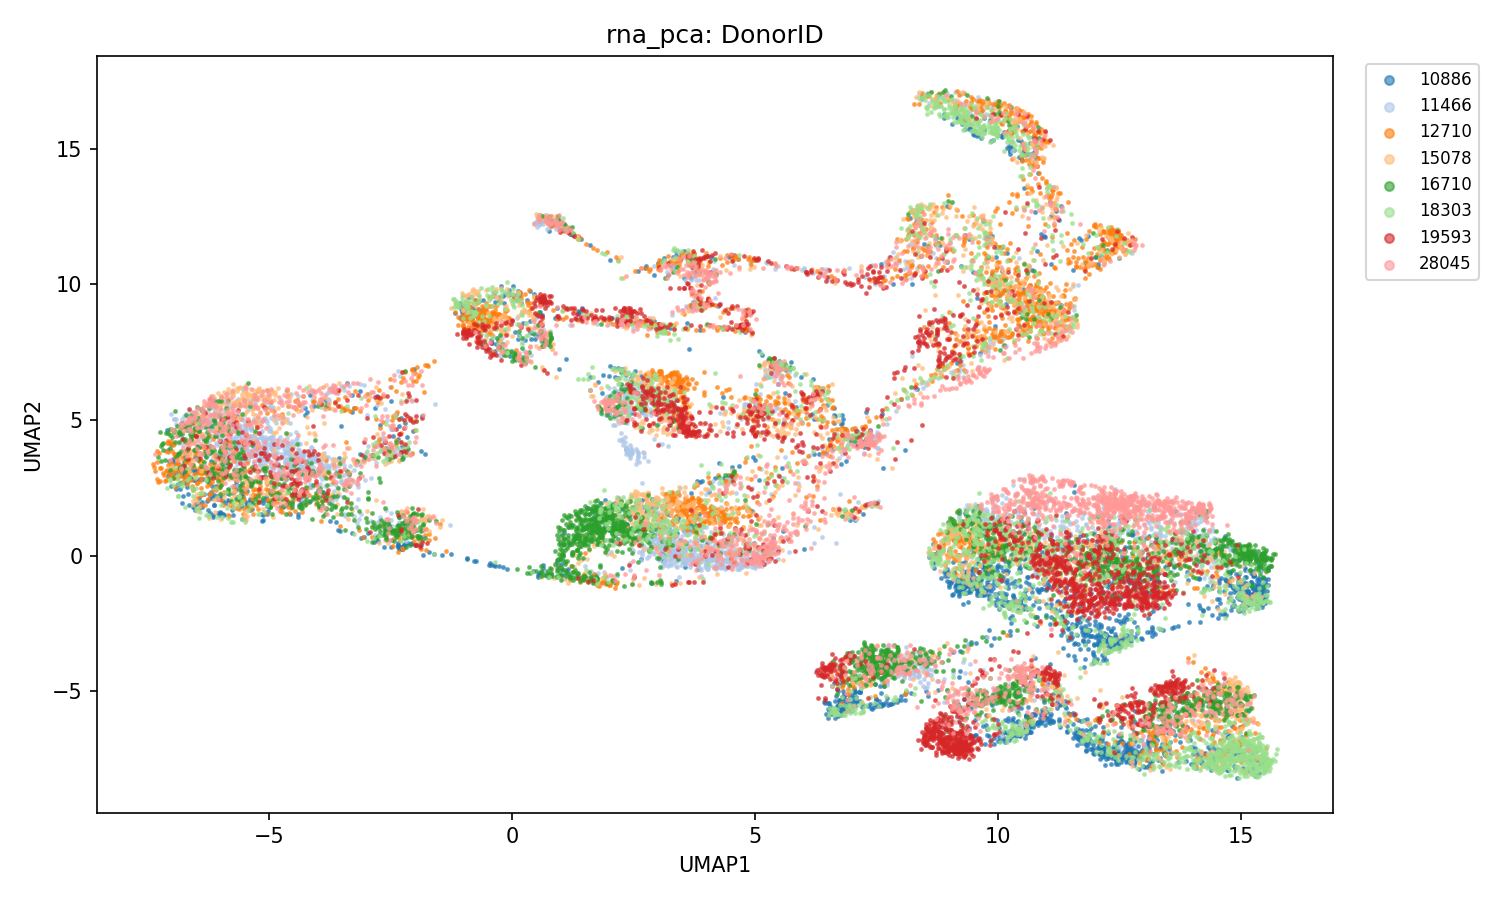

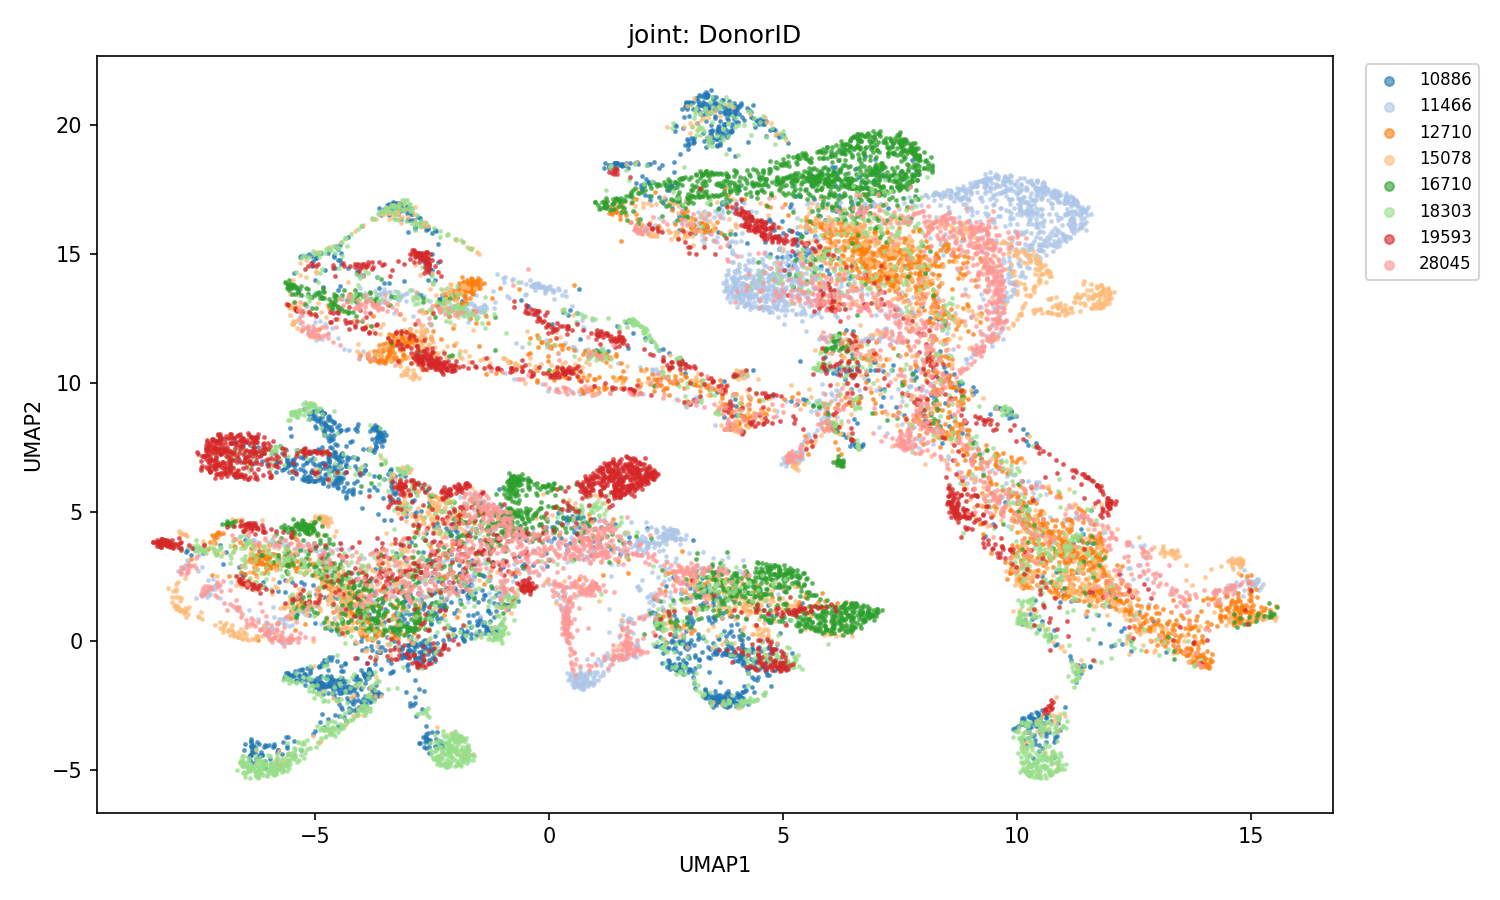

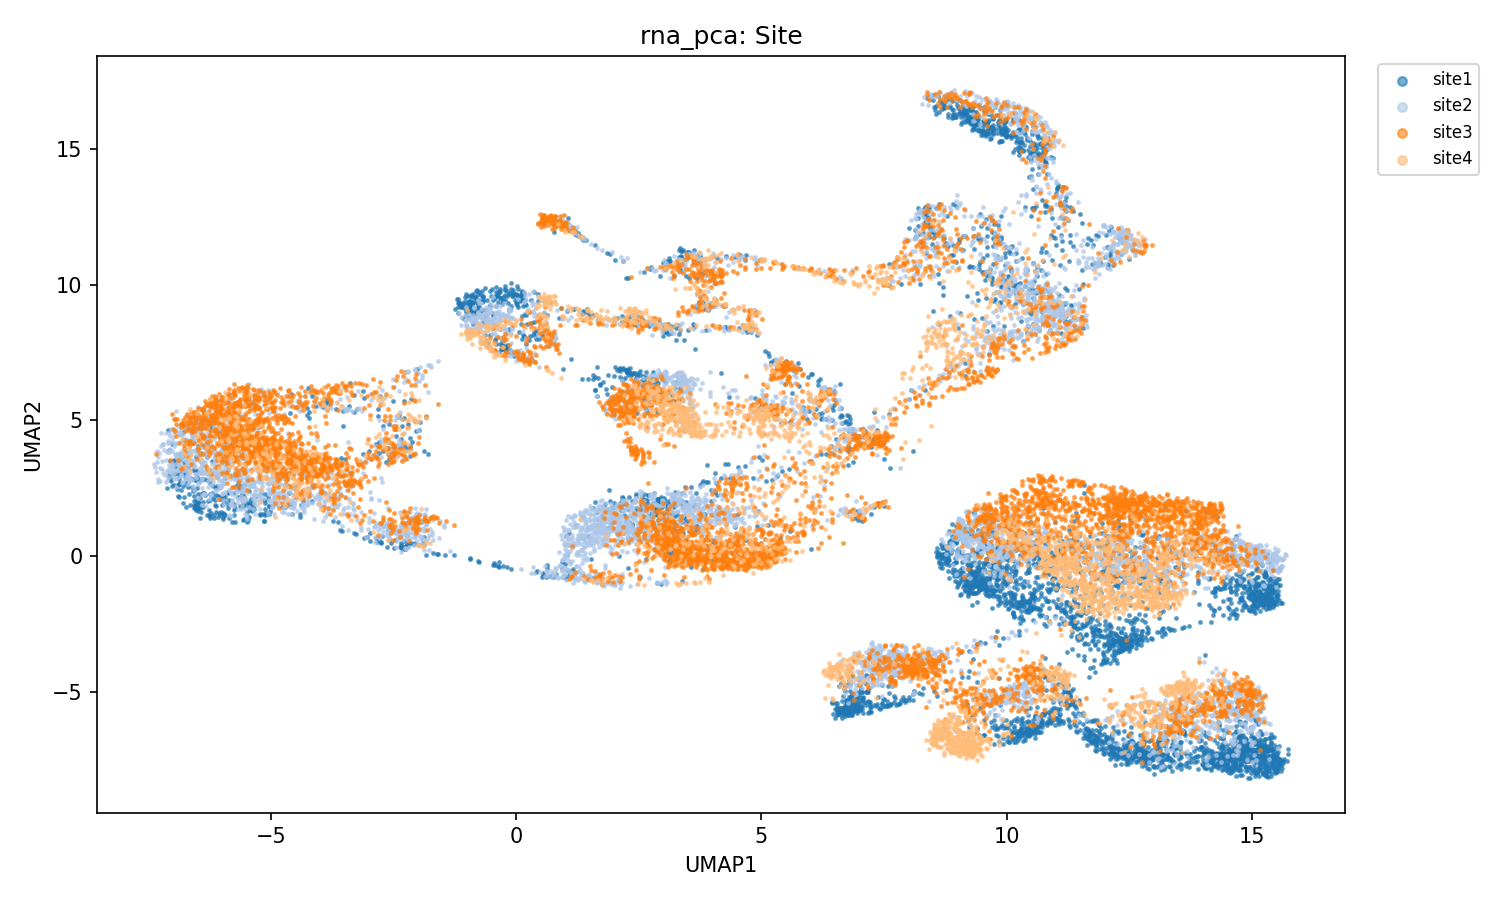

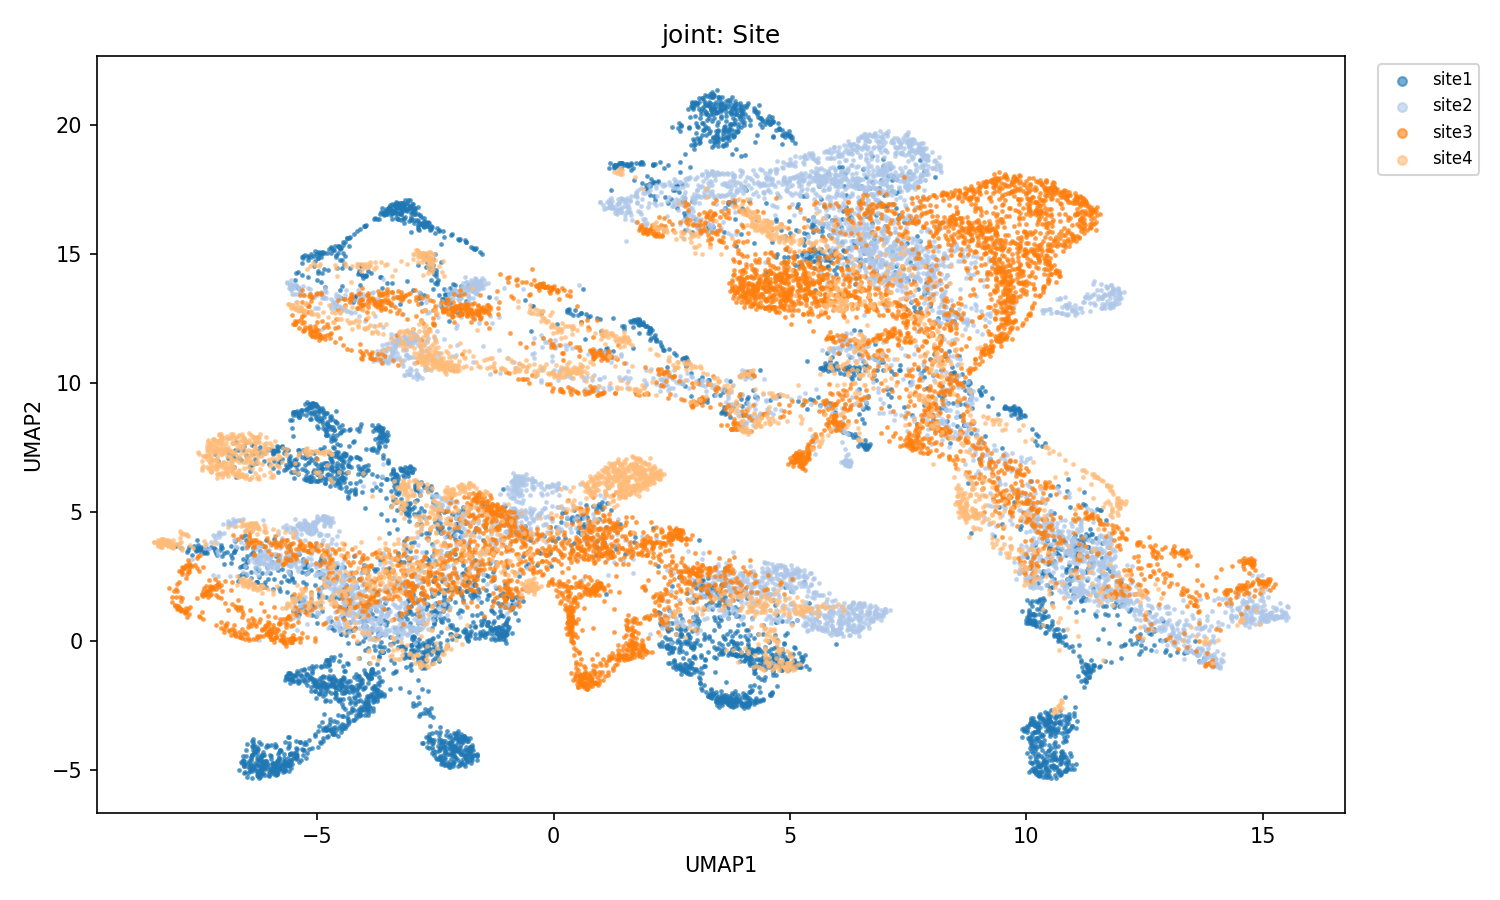

In [4]:
display(Image(filename=str(OUTPUT/'figures/training.png')))
display(comparison)
with pd.option_context('display.max_rows',None):
    display(types)
    display(donors)
display(depths)
for field in ['assay','cell_type_harmonized','DonorID','Site']:
    for space in ['rna_pca','joint']:
        display(Image(filename=str(OUTPUT/f'figures/{space}_{field}.png')))

## Findings and decision after execution
Record training convergence, assay mixing conditional on cell identity, unsupported
populations, donor agreement and depth structure. No success is assumed. A good
UMAP cannot validate unobserved protein/ATAC or demonstrate causal regulation.

This is a feature-restricted integration pilot. The nb12 prevalent-peak selection
may underrepresent rare states, and the RNA HVG intersection may omit useful genes.
If evidence is mixed, review those limitations before increasing correction.
Cross-modal predictions would require held-out observed-modality validation and
explicit labeling as predictions; they are not produced here.

## Saved artifacts
model_input.h5ad contains raw shared RNA and peaks, sparse protein counts,
observed-modality flags and joint coordinates. model/ contains weights/registry.
Input is saved before training, weights before evaluation; EVALUATE can recover
joint coordinates if needed. Hashes, manifests, CSV metrics, per-cell diagnostics,
UMAP coordinates and nine PNGs support a review. LOAD requires only the saved
analysis files. Keep the large inputs and weights on Drive for further diagnostics.